# 02. 혼잡도 패턴 분석
역별·요일별·월별 혼잡도 시각화 (일별 집계 데이터 기반)

In [1]:
import sys, os, socket

# 시스템 Spark 3.2.1 vs pip PySpark 3.5.0 충돌 방지
if 'SPARK_HOME' in os.environ:
    old_python = os.path.join(os.environ['SPARK_HOME'], 'python')
    sys.path = [p for p in sys.path if old_python not in p]
    del os.environ['SPARK_HOME']

# Windows: Java 17 경로 자동 설정
if sys.platform == 'win32':
    import subprocess
    result = subprocess.run(['where.exe', 'java'], capture_output=True, text=True)
    if result.stdout.strip():
        java_exe = result.stdout.strip().split('\n')[0].strip()
        os.environ['JAVA_HOME'] = str(os.path.dirname(os.path.dirname(java_exe)))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import socket, os

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# Windows Spark 설정
LOCAL_IP = socket.gethostbyname(socket.gethostname())
os.environ['SPARK_LOCAL_IP'] = LOCAL_IP
os.environ['HADOOP_HOME'] = 'C:\\hadoop'
os.environ['PATH'] = os.environ['PATH'] + ';C:\\hadoop\\bin'

from delta import configure_spark_with_delta_pip
from pyspark.sql import SparkSession

builder = SparkSession.builder \
    .appName('congestion_analysis') \
    .master('local[1]') \
    .config('spark.driver.host', LOCAL_IP) \
    .config('spark.driver.bindAddress', LOCAL_IP) \
    .config('spark.ui.enabled', 'false') \
    .config('spark.sql.extensions', 'io.delta.sql.DeltaSparkSessionExtension') \
    .config('spark.sql.catalog.spark_catalog', 'org.apache.spark.sql.delta.catalog.DeltaCatalog')

spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

In [2]:
# Gold - 역별 평균 일 승하차 로드
df_daily = spark.read.format('delta').load('data/gold/congestion_daily_avg').toPandas()
print(f'역 수: {len(df_daily):,}')
df_daily.head(10)

역 수: 621


,line_num,subway_sta_nm,avg_ride,avg_alight,max_ride,max_alight,data_days
0,3호선,무악재,4357.566667,4353.400000,5217,5209,30
1,경의선,금릉,5112.500000,4979.733333,5980,5919,30
2,3호선,수서,19055.833333,18641.633333,22779,22261,30
3,경원선,방학,10449.700000,10240.400000,11971,11677,30
4,9호선2~3단계,언주,11143.666667,11319.333333,14229,14410,30
5,1호선,종로3가,26615.400000,23659.700000,32711,30032,30
6,1호선,동대문,13973.566667,13621.166667,15489,15511,30
7,공항철도 1호선,인천공항2터미널,12245.866667,9930.866667,14026,11741,30
8,7호선,대림(구로구청),9532.800000,9503.633333,9935,9890,30
9,경강선,여주,3505.266667,3453.633333,3824,4138,30


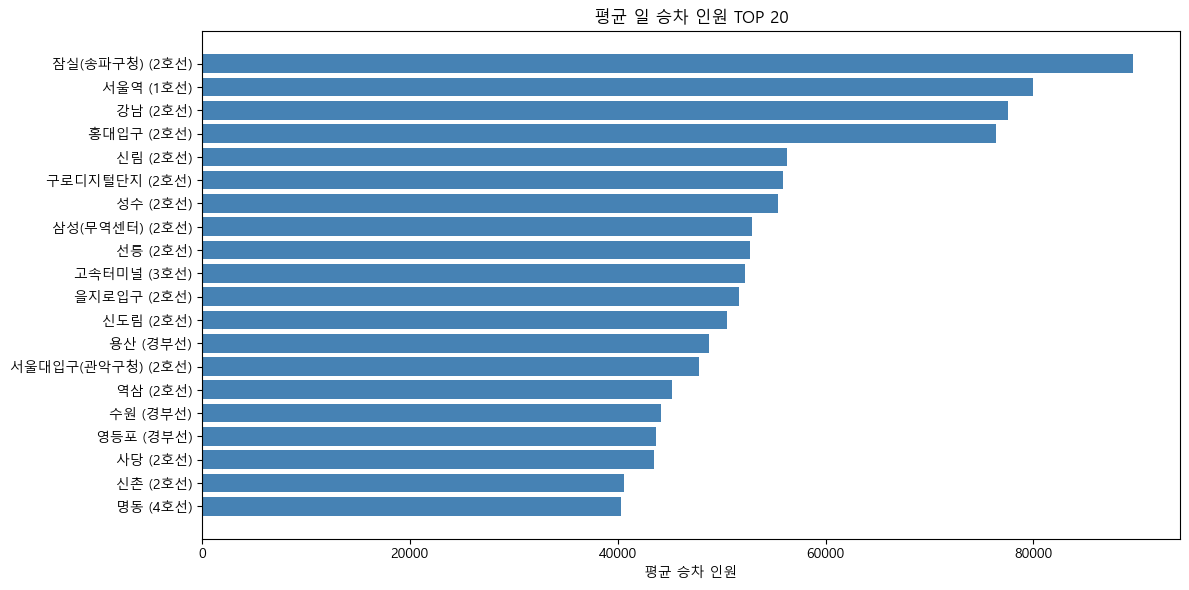

In [3]:
# 전체 상위 역 랭킹 TOP 20 (평균 승차 기준)
top20 = df_daily.sort_values('avg_ride', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20['subway_sta_nm'] + ' (' + top20['line_num'] + ')',
        top20['avg_ride'], color='steelblue')
ax.set_title('평균 일 승차 인원 TOP 20')
ax.set_xlabel('평균 승차 인원')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

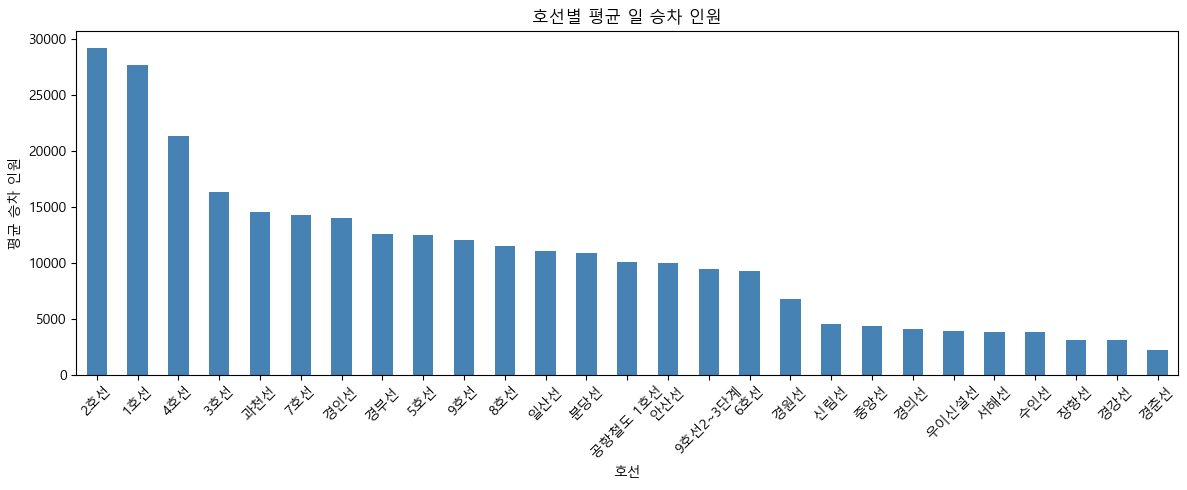

In [4]:
# 호선별 평균 승차 인원 비교
line_avg = df_daily.groupby('line_num')['avg_ride'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
line_avg.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('호선별 평균 일 승차 인원')
ax.set_xlabel('호선')
ax.set_ylabel('평균 승차 인원')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

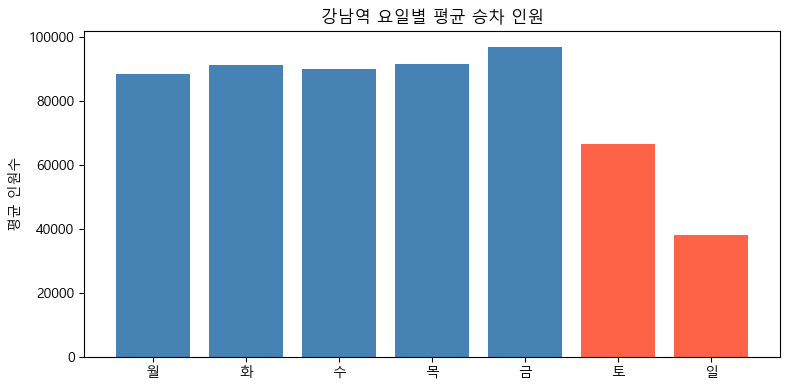

In [5]:
# Gold - 요일별 혼잡도 로드
df_weekly = spark.read.format('delta').load('data/gold/congestion_weekly').toPandas()

day_map = {1: '일', 2: '월', 3: '화', 4: '수', 5: '목', 6: '금', 7: '토'}
df_weekly['day_label'] = df_weekly['day_of_week'].map(day_map)

# 특정 역 요일별 승하차 패턴 (예: 강남)
station = '강남'
df_sta_week = df_weekly[df_weekly['subway_sta_nm'] == station]
df_grouped = df_sta_week.groupby('day_label')['avg_ride'].mean() \
    .reindex(['월', '화', '수', '목', '금', '토', '일'])

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if d in ['토', '일'] else 'steelblue' for d in df_grouped.index]
ax.bar(df_grouped.index, df_grouped.values, color=colors)
ax.set_title(f'{station}역 요일별 평균 승차 인원')
ax.set_ylabel('평균 인원수')
plt.tight_layout()
plt.show()

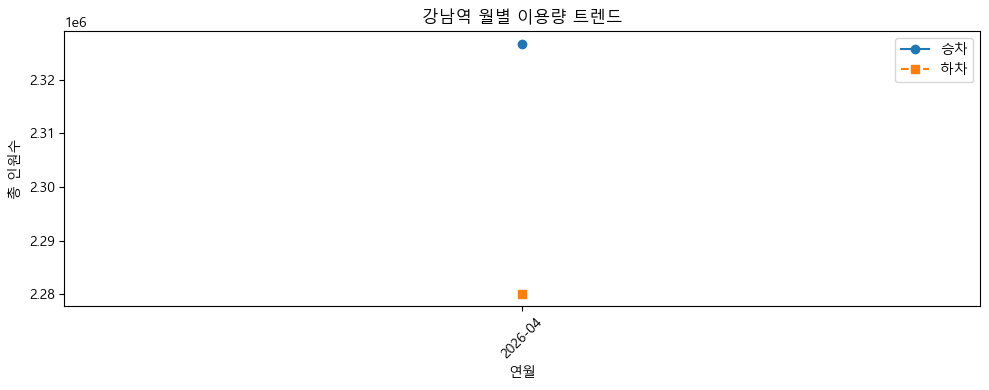

In [6]:
# Gold - 월별 트렌드 로드
df_monthly = spark.read.format('delta').load('data/gold/congestion_monthly').toPandas()

# 특정 역 월별 승하차 추이
station = '강남'
df_sta_month = df_monthly[df_monthly['subway_sta_nm'] == station].sort_values('year_month')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sta_month['year_month'], df_sta_month['total_ride'], marker='o', label='승차')
ax.plot(df_sta_month['year_month'], df_sta_month['total_alight'], marker='s', linestyle='--', label='하차')
ax.set_title(f'{station}역 월별 이용량 트렌드')
ax.set_xlabel('연월')
ax.set_ylabel('총 인원수')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [7]:
spark.stop()